In [1]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1"
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from scipy.io import savemat
from scipy.interpolate import interp1d
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import matplotlib.font_manager as fm
from scipy.io import savemat
from matplotlib import font_manager

In [2]:
prop=pd.read_csv('combinedfeatureset_correct.csv')

In [3]:
prop=prop[['Nucleus_RIstd','Nucleus_area','Nucleolus_area','Lipid_area','Cell_area','Cytoplasm_Ratio','Nucleolus_Ratio','Lipid_Ratio','Cell_RI','Nucleus_RI','Nucleolus_RI','Lipid_RI','Nucleus to Cell Area Ratio','Nucleolus to Nucleus Ratio','Cell Volume','Cell Thickness']]

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import scanpy as sc

In [5]:
adata = sc.AnnData(X=prop)

c:\Users\anous\anaconda3\envs\scanpy\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
sc.pp.scale(adata, max_value=10)

In [7]:
sc.tl.pca(adata, n_comps=15, svd_solver='arpack')

In [8]:
import numpy as np
cumvar = np.cumsum(adata.uns['pca']['variance_ratio'])
for i, v in enumerate(cumvar):
    if v > 0.80:
        print(f"80% variance explained at PC{i+1}")
        break

80% variance explained at PC4


In [9]:
sc.tl.pca(adata, n_comps=4, svd_solver='arpack')

In [10]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca', metric='euclidean')
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')
sc.tl.umap(adata, min_dist=0.1, spread=1, random_state=42)

c:\Users\anous\anaconda3\envs\scanpy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\anous\AppData\Local\Temp\ipykernel_13956\2398398688.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')


In [11]:
from sklearn import metrics
from scipy.spatial.distance import cdist

In [12]:
font_path=r'C:\Users\anous\Downloads\Roboto (1)\Roboto-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
plt.rcParams['font.family']=font_prop.get_name()
sns.set_palette('deep')

In [13]:
sns.set_context('talk')

In [14]:
reference=pd.read_csv('combinedfeatureset_correct.csv')

In [15]:
supervised_labels = np.array(reference['Type'])

In [16]:
groups=['Parental','CarboplatinR','PaclitaxelR','EpirubicinR']
adata.obs['true_labels'] = pd.Categorical(reference['Type'], categories=groups, ordered=True)

In [17]:
adata.obs["true_labels"].values

['PaclitaxelR', 'PaclitaxelR', 'PaclitaxelR', 'PaclitaxelR', 'PaclitaxelR', ..., 'Parental', 'Parental', 'Parental', 'Parental', 'Parental']
Length: 568
Categories (4, object): ['Parental' < 'CarboplatinR' < 'PaclitaxelR' < 'EpirubicinR']

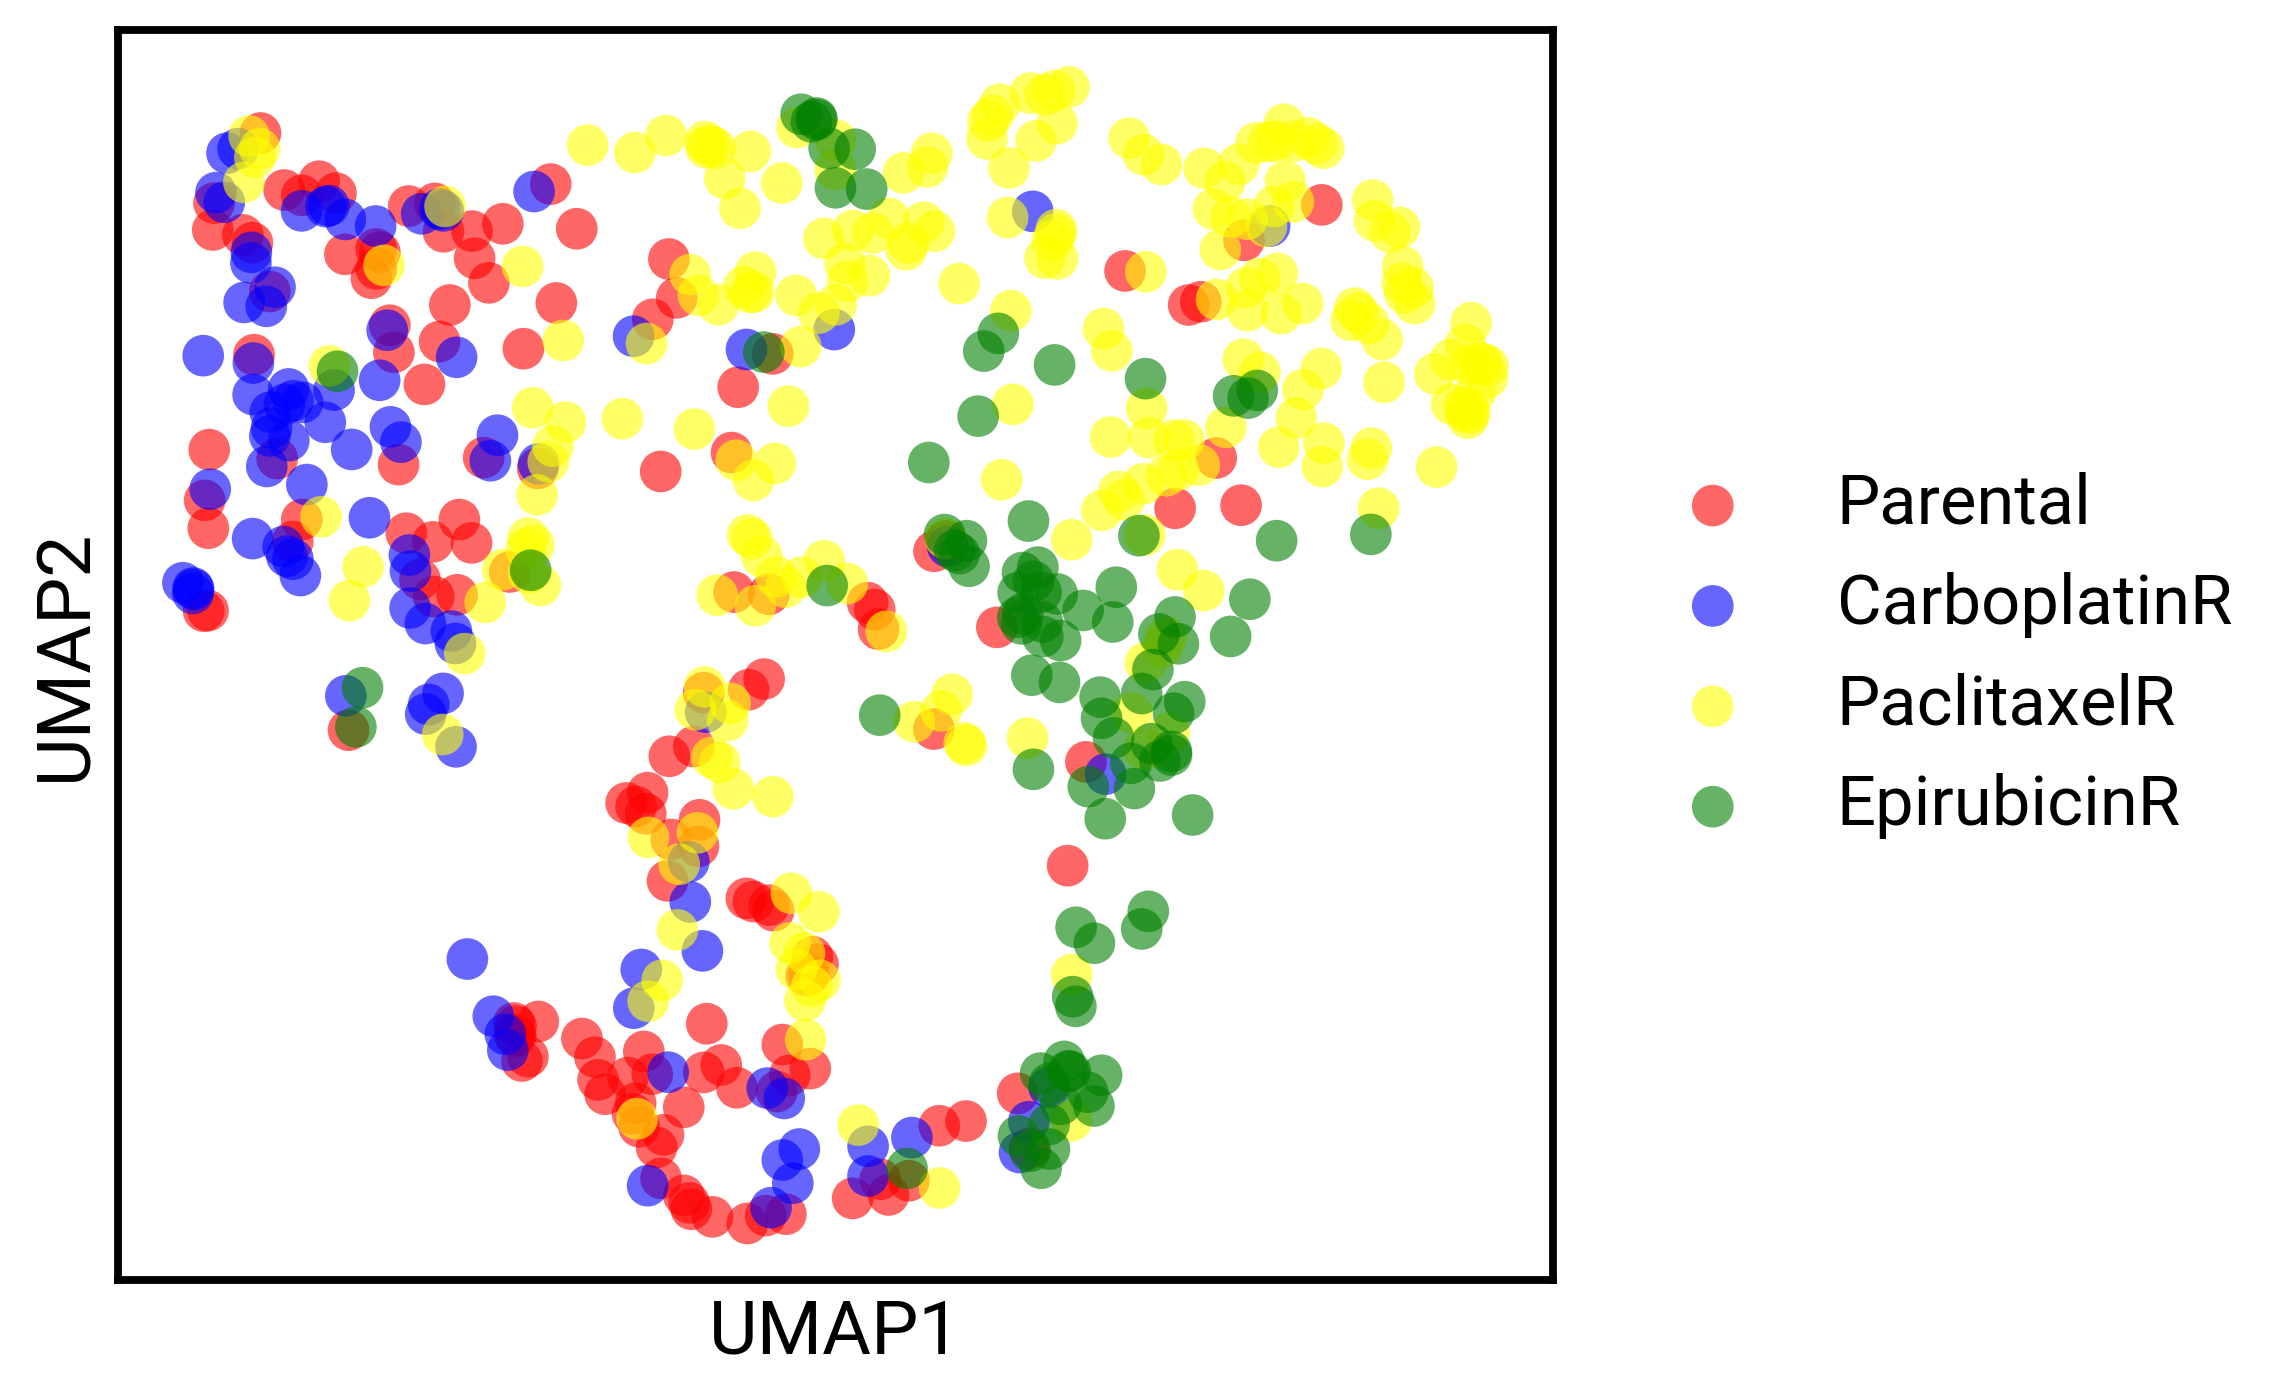

In [18]:
X = adata.obsm["X_umap"]
x, y = X[:, 0], X[:, 1]

# Normalize to [0,1]
x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

labels = adata.obs["true_labels"].values

fig, ax = plt.subplots(figsize=(8,5), dpi=300)
palette = { "Parental": "red", "CarboplatinR": "blue", "PaclitaxelR": "yellow", "EpirubicinR": "green" }
for lab, col in palette.items():
    m = (labels == lab)
    ax.scatter(x_norm[m], y_norm[m], s=100, c=col, alpha=0.6, edgecolors="none", label=lab)

# axis matches grid
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig("umap_supervisedlabels_norm01.svg", bbox_inches="tight")
plt.show()

In [19]:
embedding_pca=np.array(adata.obsm['X_umap'])

In [20]:
filenamedf=pd.read_csv('dino_features_matched_fullfilenames.csv')

In [21]:
filenamedf

,filename,0,1,2,3,4,5,6,7,8,...,758,759,760,761,762,763,764,765,766,767
0,20240227.161551.545.MDAMB231Pack-002Stitching_...,2.008431,-0.554484,0.551581,-1.714546,0.809011,-1.950643,0.400103,0.461679,2.367981,...,-0.245035,0.023325,-2.844513,-0.512531,3.637291,0.066388,0.263382,0.494711,0.194114,-2.246911
1,20240227.162458.587.MDAMB231Pack-006Stitching_...,0.111024,1.863824,-0.290265,-0.505017,0.140275,-3.618313,-1.456136,-0.209994,2.437693,...,1.258070,1.566166,-2.366845,1.147259,2.194895,0.283572,-0.707509,1.631179,0.736506,-4.753220
2,20240227.163029.167.MDAMB231Pack-009Stitching_...,2.618959,-0.603491,1.431700,-0.618850,-0.970031,-2.567108,0.109664,-0.126926,1.600448,...,0.557470,-0.777628,-1.892909,0.367424,3.490121,-1.896964,0.390765,0.306641,0.228559,-2.272253
3,20240227.163151.382.MDAMB231Pack-010Stitching_...,2.873716,0.614102,0.610306,-1.426129,0.284832,-1.958784,1.071341,-0.892071,2.248831,...,1.295983,-0.782941,-2.506328,0.637091,4.652208,-1.265487,0.838730,-0.066006,0.664859,-2.338901
4,20240227.163305.817.MDAMB231Pack-011Stitching_...,2.429022,-1.112948,0.146736,-1.223091,-0.319102,-2.013888,0.503773,-0.164641,1.774123,...,0.037244,-0.862162,-1.985468,0.465869,2.320171,-0.012903,-0.668744,1.055400,-1.665590,-1.738008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,20240705.112318.012.parental_r1-002_HT2D_0_sub...,1.833572,0.278359,0.917116,-2.276660,-1.255094,-1.626339,0.901998,-0.454371,2.041961,...,0.701149,-0.145234,-1.432485,1.058171,3.176613,-1.322658,-0.081571,0.680488,-0.634871,-1.861130
564,20240705.112353.562.parental_r1-003_HT2D_0_sub...,2.451252,1.130822,1.151308,-1.107863,1.081192,-2.033641,0.370880,-1.164507,1.747712,...,1.071367,0.101324,-1.822919,0.637995,4.414327,-0.919792,0.289790,1.020790,0.260538,-2.142441
565,20240705.112558.078.parental_r1-004_HT2D_0_sub...,2.348735,0.286008,1.680825,-1.091673,-1.150265,-1.768972,0.957224,-0.755178,2.177179,...,-0.395554,0.219307,-1.485639,1.195530,2.223650,-2.395111,0.157375,0.573600,-0.113909,-1.394473
566,20240705.113315.810.parental_r1-009_HT2D_0_sub...,2.151099,0.558705,1.470418,-0.566634,0.484612,-1.413166,1.060793,-1.421447,1.679161,...,-0.016718,-0.606422,-2.562017,1.223823,4.087571,-1.821310,0.791275,1.009199,1.165263,-1.746534


In [22]:
filenamelist=filenamedf['filename'].tolist()


In [23]:
from PIL import Image

In [24]:
folder_path=r'C:\Users\anous\OneDrive - Johns Hopkins\2026_datanalysis\Dinostore568_cropped'
processed_images = []
for i,img_name in enumerate(filenamelist):
    img_path = os.path.join(folder_path, img_name)
    img = Image.open(img_path).convert('L')
    img_resized=img.resize((300,125))
    img_array = np.array(img_resized).astype(np.float32)
    img_array[img_array ==0]=np.nan
    processed_images.append(img_array)

processed_images_np = np.array(processed_images)
print(processed_images_np.shape)

(568, 125, 300)


In [27]:
cell_area=reference['Cell Area Total'].values

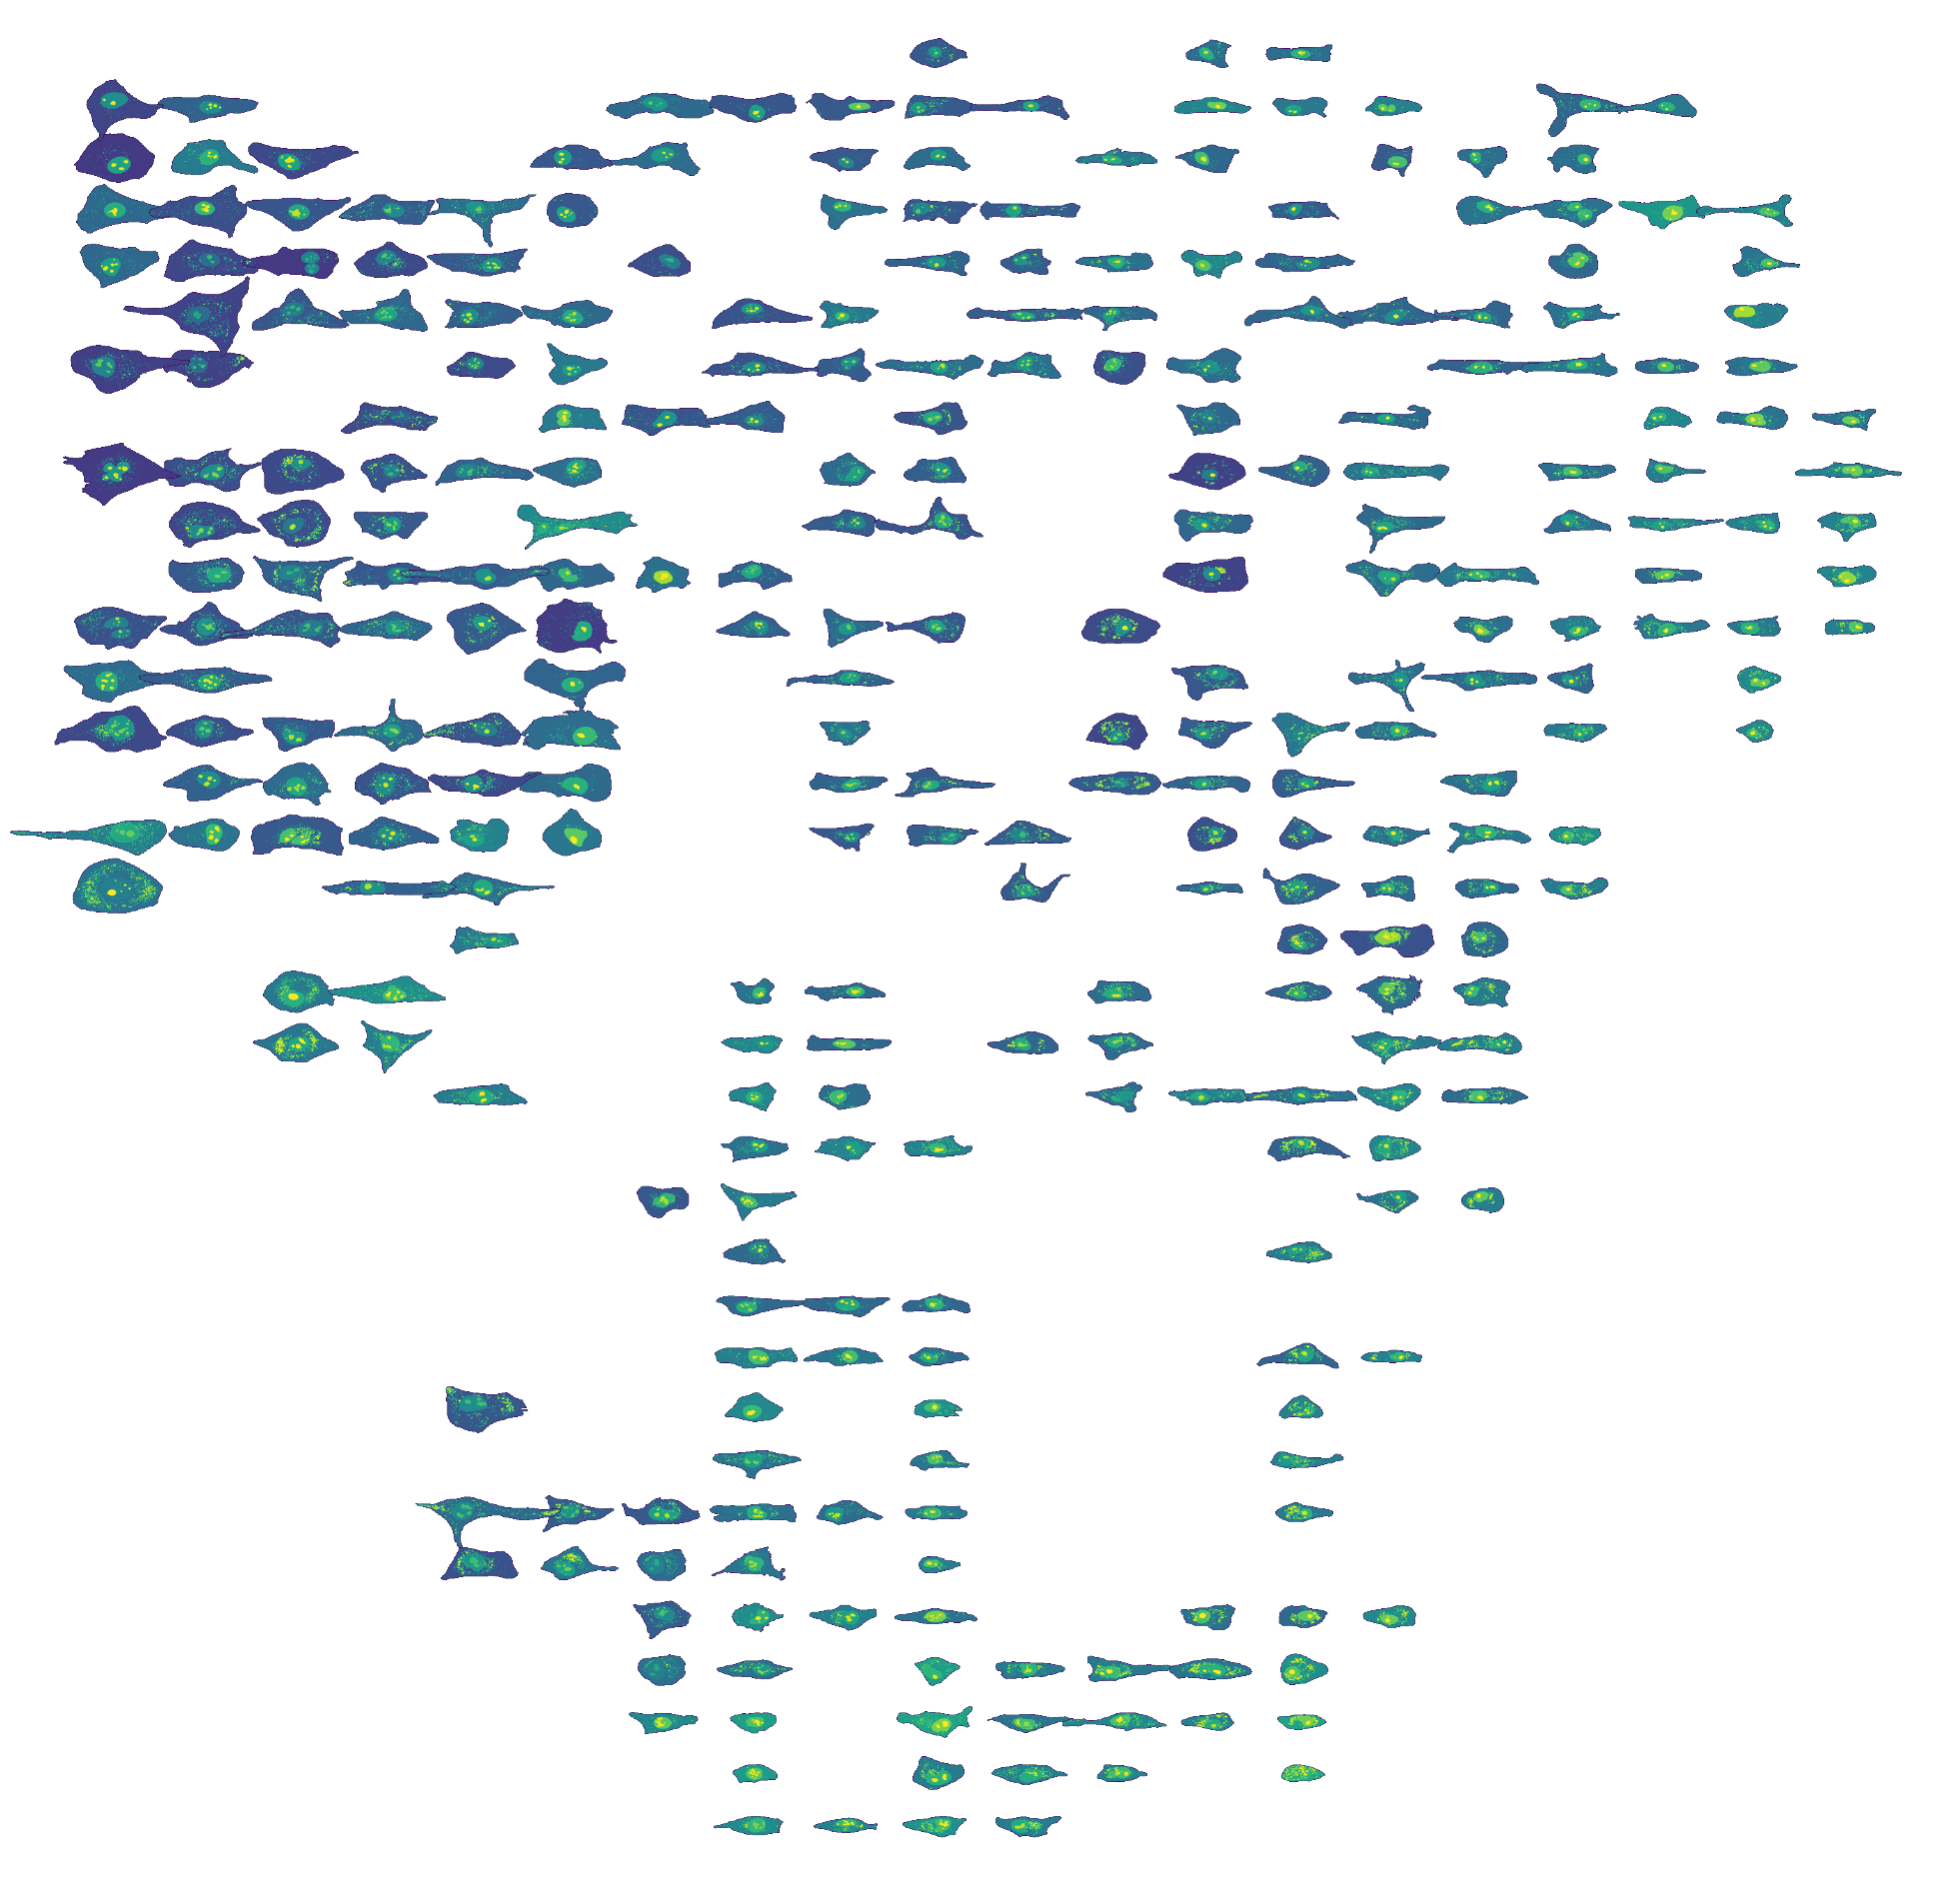

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def umap_grid_bin_thumbnails(
    embedding, images,
    cell_area=None,
    n_bins_x=35,
    n_bins_y=15,
    zoom=0.10,
    figsize=(20, 20),
    place_at="bin_center",          # "bin_center" or "point"
    pick="closest_to_center",       # "closest_to_center", "max_area", "median_area"
    min_area=None                   # optional: ignore tiny cells
):
    """
    embedding: (N,2)
    images: list/array length N, each (H,W) or (H,W,3)
    cell_area: array length N (optional)
    """

    x = embedding[:, 0].astype(float)
    y = embedding[:, 1].astype(float)

    # Normalize to [0,1]
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

    # Bin indices
    bx = np.clip((x_norm * n_bins_x).astype(int), 0, n_bins_x - 1)
    by = np.clip((y_norm * n_bins_y).astype(int), 0, n_bins_y - 1)

    x_centers = (np.arange(n_bins_x) + 0.5) / n_bins_x
    y_centers = (np.arange(n_bins_y) + 0.5) / n_bins_y

    # Group points by bin
    bin_to_indices = {}
    for i in range(len(images)):
        if min_area is not None and cell_area is not None and cell_area[i] < min_area:
            continue
        key = (bx[i], by[i])
        bin_to_indices.setdefault(key, []).append(i)

    # Pick representative per bin
    bin_to_rep = {}
    for key, idxs in bin_to_indices.items():
        cx = x_centers[key[0]]
        cy = y_centers[key[1]]

        if pick == "closest_to_center":
            d2 = [(i, (x_norm[i]-cx)**2 + (y_norm[i]-cy)**2) for i in idxs]
            rep = min(d2, key=lambda t: t[1])[0]

        elif pick == "max_area":
            if cell_area is None:
                raise ValueError("cell_area is required for pick='max_area'")
            rep = max(idxs, key=lambda i: cell_area[i])

        elif pick == "median_area":
            if cell_area is None:
                raise ValueError("cell_area is required for pick='median_area'")
            # pick index whose area is closest to the median in that bin
            areas = np.array([cell_area[i] for i in idxs])
            med = np.median(areas)
            rep = idxs[int(np.argmin(np.abs(areas - med)))]

        else:
            raise ValueError("pick must be: closest_to_center | max_area | median_area")

        bin_to_rep[key] = rep

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal"); ax.axis("off")

    for key, rep_i in bin_to_rep.items():
        img = images[rep_i]
        if img is None:
            continue

        imagebox = OffsetImage(img, zoom=zoom)

        if place_at == "bin_center":
            px = x_centers[key[0]]
            py = y_centers[key[1]]
        elif place_at == "point":
            px = x_norm[rep_i]
            py = y_norm[rep_i]
        else:
            raise ValueError("place_at must be 'bin_center' or 'point'")

        ab = AnnotationBbox(imagebox, (px, py), frameon=False, pad=0)
        ax.add_artist(ab)

    plt.tight_layout()
    plt.savefig('umap_celloverlay.svg',bbox_inches='tight',dpi=300)
    #plt.show()

    selected_idx = list(bin_to_rep.values())
    return selected_idx

# ---- recommended call for you ----
selected_idx = umap_grid_bin_thumbnails(
    embedding_pca,
    processed_images_np,
    cell_area=cell_area,     # <-- your array length 568
    n_bins_x = 20,
    n_bins_y = 35,
    zoom=0.5,
    place_at="bin_center",
    pick="closest_to_center"       # or "closest_to_center" or "max_area"
)

C:\Users\anous\AppData\Local\Temp\ipykernel_33584\3968634319.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))


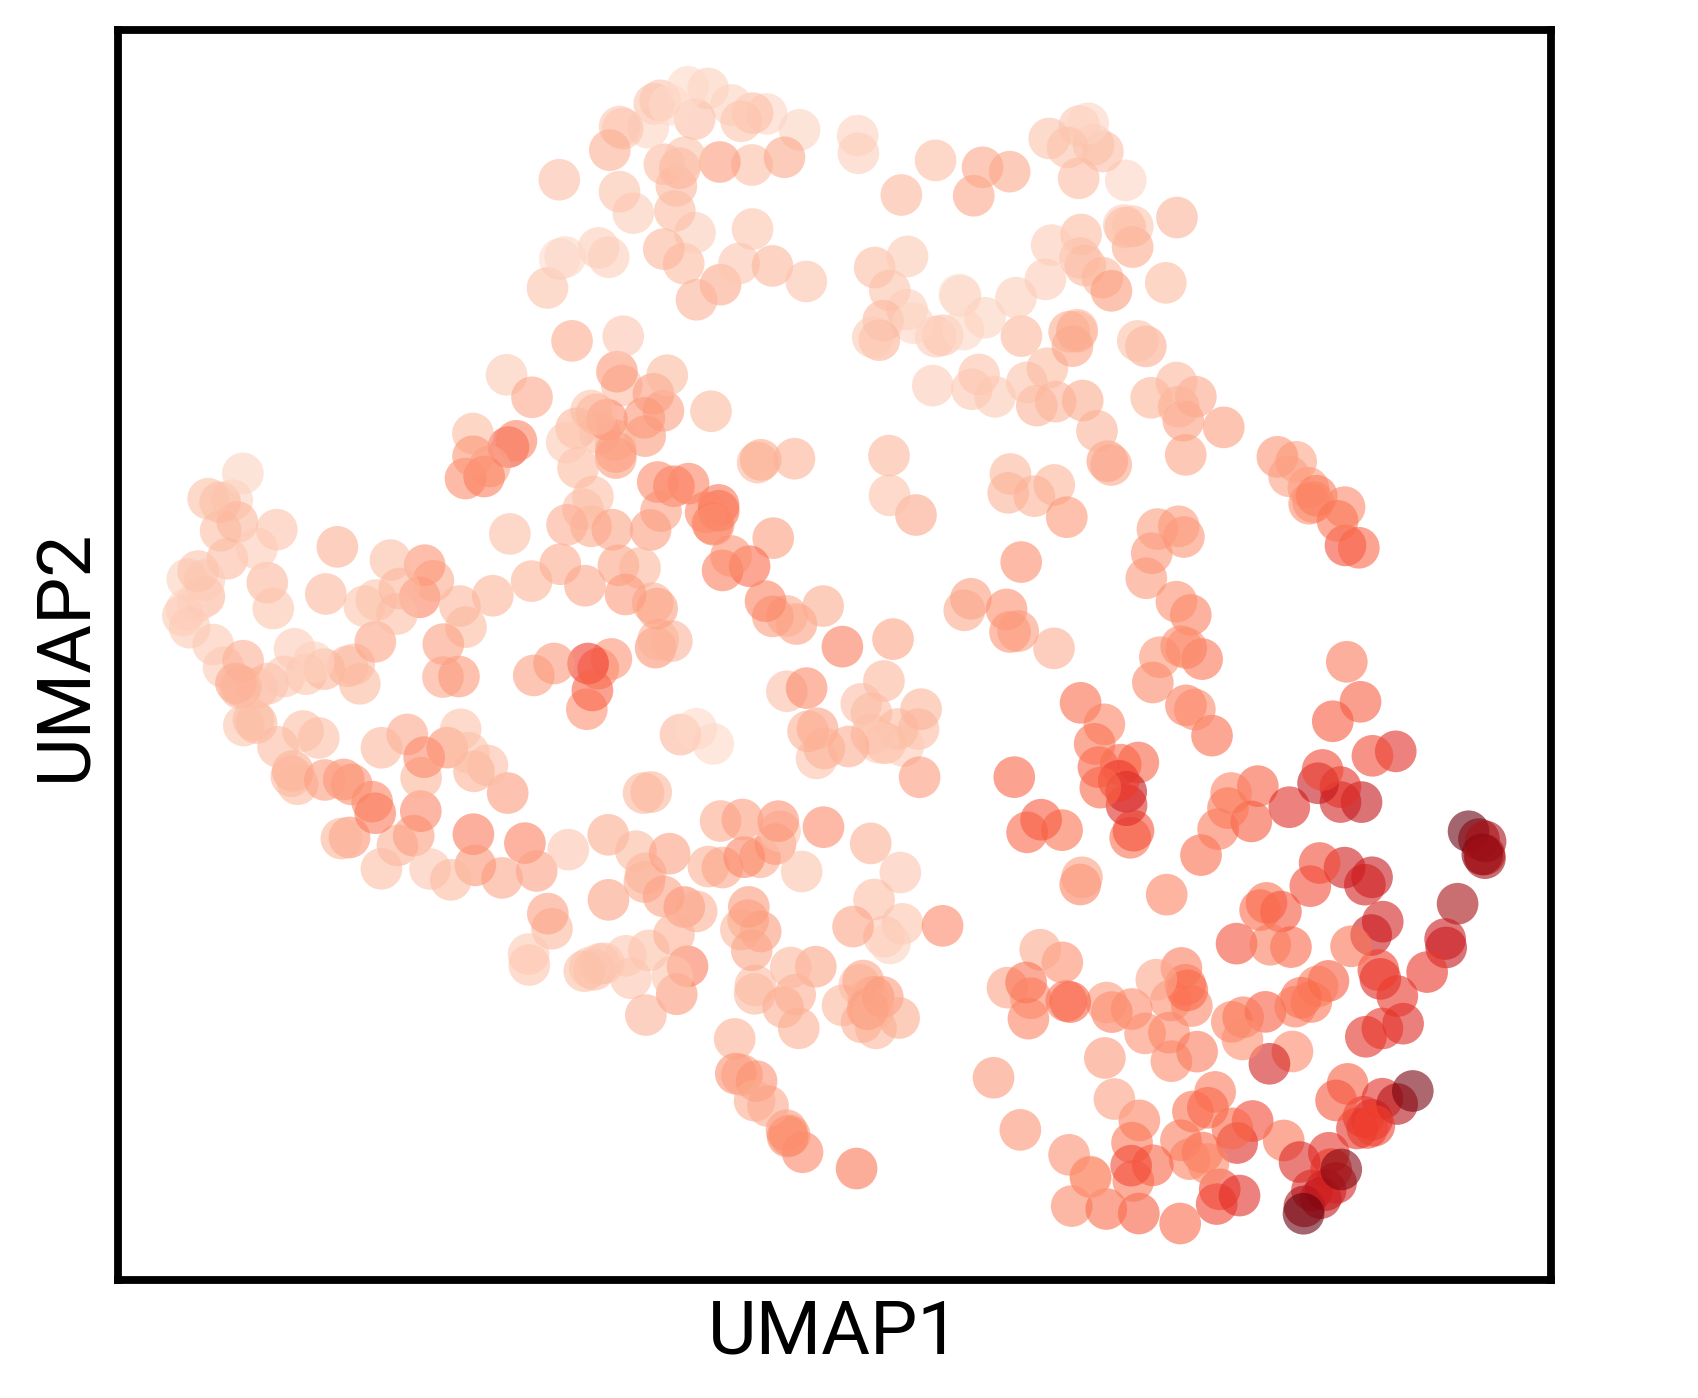

In [28]:
adata.obs['cell area'] = reference['Cell Area Total'].values

# Extract UMAP
X = adata.obsm["X_umap"]
x, y = X[:, 0], X[:, 1]

# Normalize to [0,1]  (same as your grid)
x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

area = adata.obs['cell area'].values

fig, ax = plt.subplots(figsize=(6,5), dpi=300)

ax.scatter(
    x_norm,
    y_norm,
    c=area,
    cmap="Reds",
    s=100,
    vmin=0,
    alpha=0.6,
    vmax=3000,
    edgecolors="none"
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig("umap_areaoverlay_norm01colorbar.svg", bbox_inches="tight")
plt.show()

In [29]:
pos = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)
pos["group"] = adata.obs['leiden_0.5']

In [30]:
from sklearn.cluster import KMeans

In [31]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10) 
kmeans.fit(prop)

# Store the cluster assignments in adata.obs
adata.obs['kmeans_clusters'] = pd.Categorical(kmeans.labels_.astype(str))

C:\Users\anous\AppData\Local\Temp\ipykernel_33584\1759975157.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))


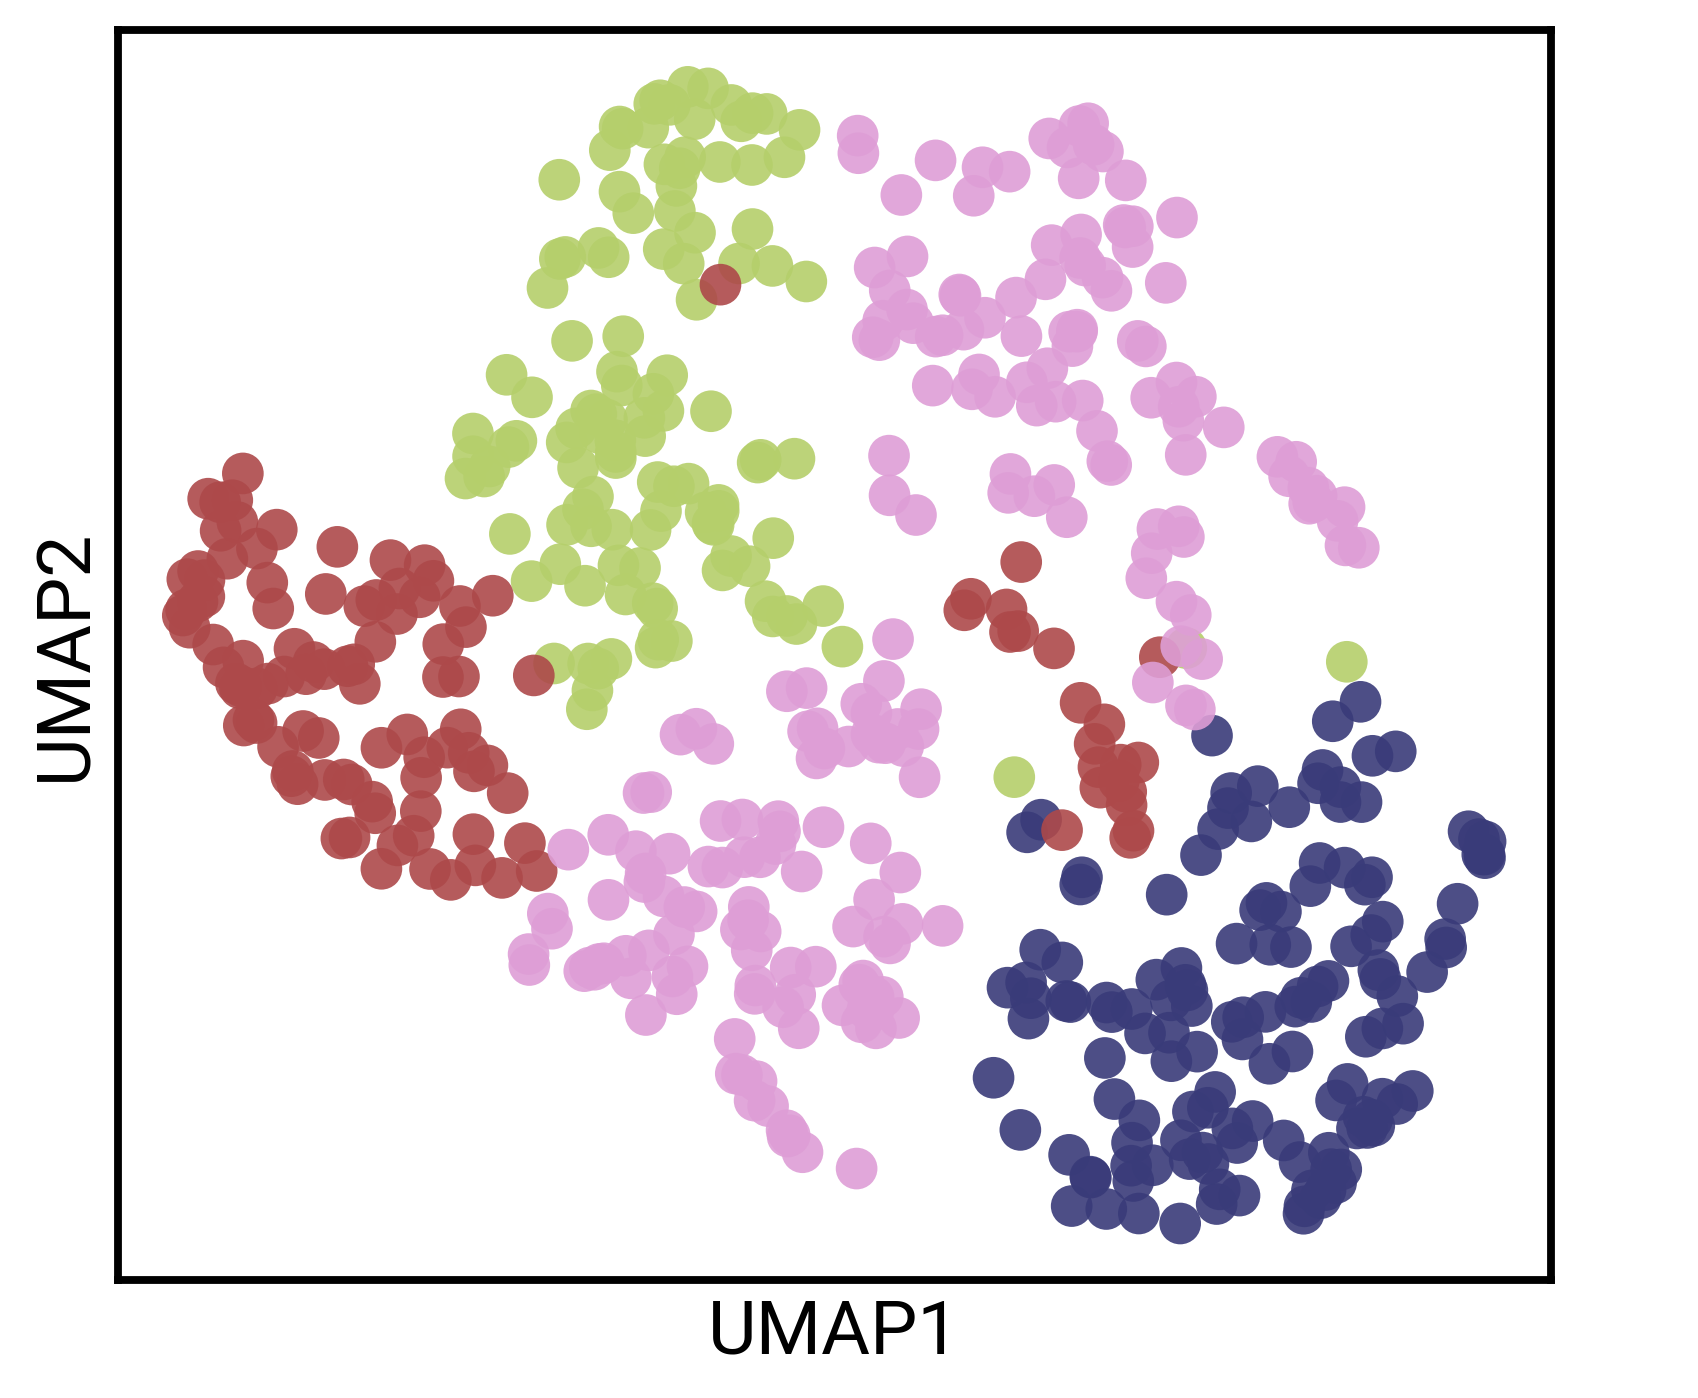

In [32]:
X = adata.obsm["X_umap"]
x, y = X[:, 0], X[:, 1]

# Normalize to [0,1] (same as your grid)
x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

clusters = adata.obs["leiden_0.5"].astype(str).values
uniq = np.unique(clusters)

fig, ax = plt.subplots(figsize=(6,5), dpi=300)
n_clusters=4
# simple categorical colors (you can replace with your own palette if you want)
cmap = plt.get_cmap("tab20b",4)
#color_map = {u: cmap(i % 3) for i, u in enumerate(uniq)}
#colors = [cmap(i / (n_clusters - 1)) for i in range(n_clusters)]
for i, u in enumerate(uniq):
    m = (clusters == u)
    ax.scatter(
        x_norm[m], y_norm[m],
        s=100,alpha=0.9,
        color=cmap(i),
        edgecolors="none",
    )

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig("umap_leiden_gridaligned.svg", bbox_inches="tight")
plt.show()

c:\Users\anous\anaconda3\envs\scanpy\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\anous\anaconda3\envs\scanpy\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\anous\anaconda3\envs\scanpy\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\anous\anaconda3\envs\scanpy\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\anous\anaconda3\envs\scanpy\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


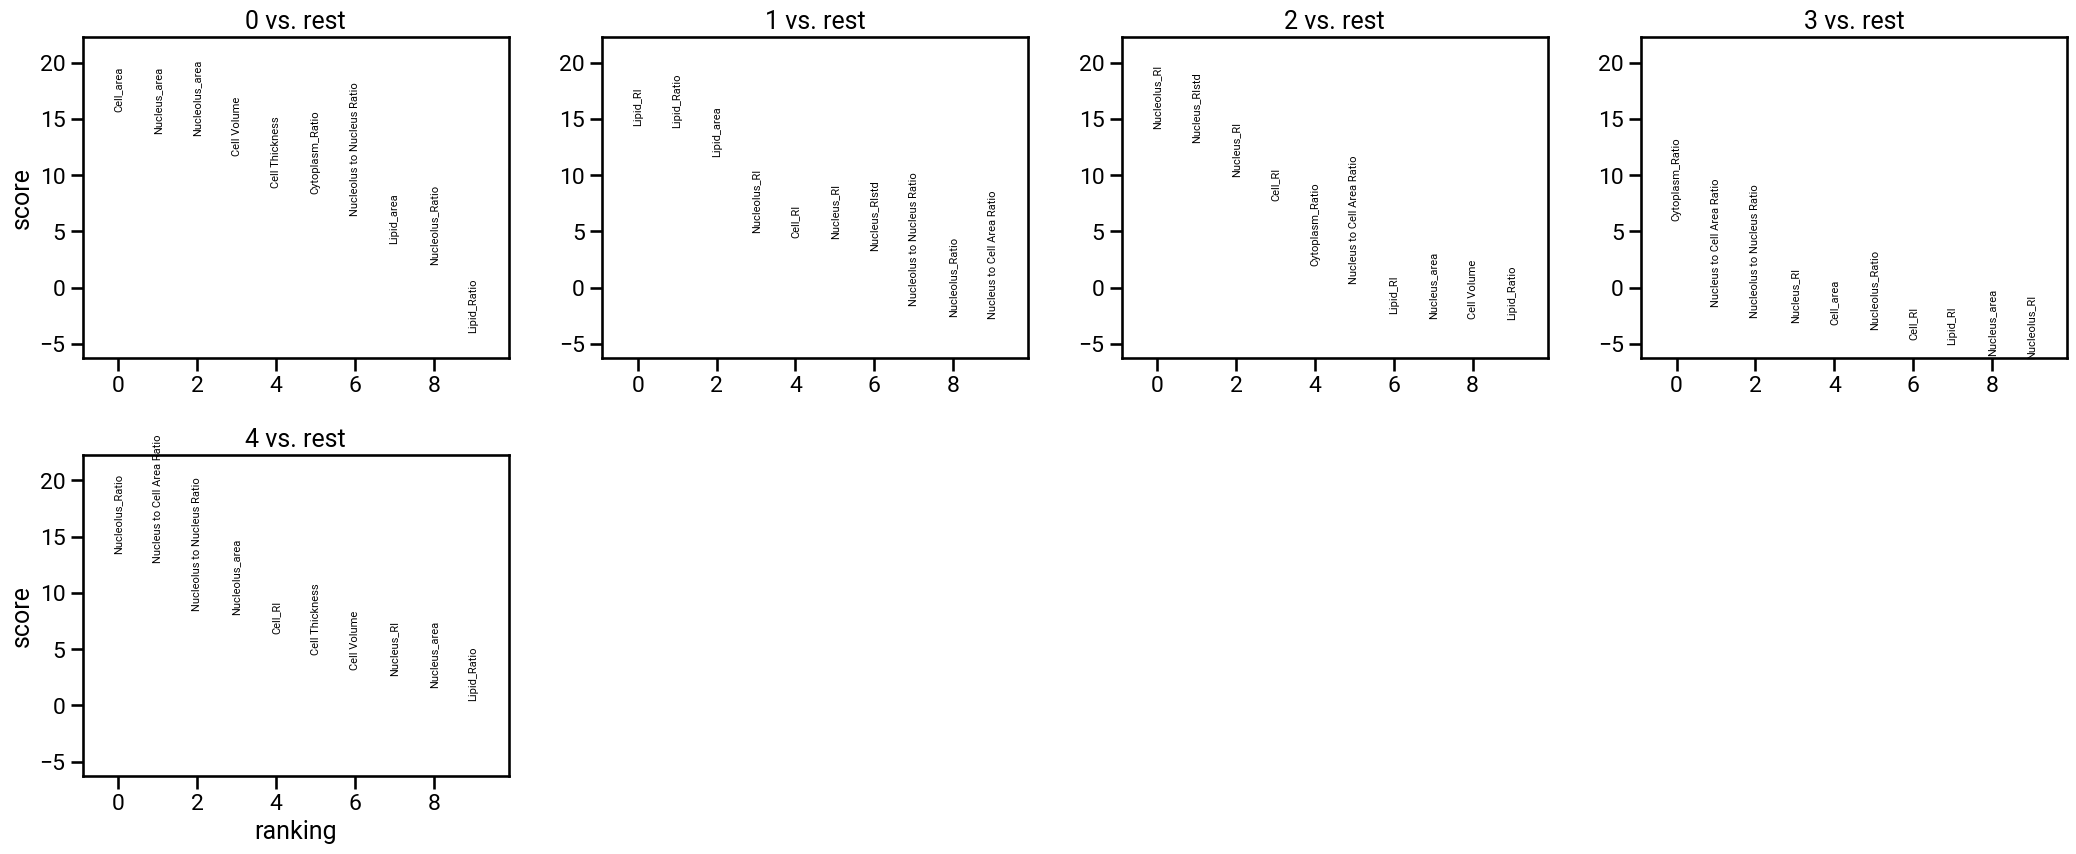

In [33]:
sc.tl.rank_genes_groups(adata, groupby='leiden_0.5', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10)

In [34]:
result = adata.uns['rank_genes_groups']
top_per_cluster = [result['names'][str(i)][:3] for i in range(4)]  
# flatten and get unique
all_top = list(set([f for sublist in top_per_cluster for f in sublist]))
print(f"Unique top features across all clusters: {len(all_top)}")
print(all_top)

Unique top features across all clusters: 12
['Nucleolus_RI', 'Cell_area', 'Lipid_Ratio', 'Lipid_RI', 'Nucleus_RIstd', 'Nucleus_area', 'Nucleus_RI', 'Nucleolus to Nucleus Ratio', 'Cytoplasm_Ratio', 'Lipid_area', 'Nucleus to Cell Area Ratio', 'Nucleolus_area']


In [33]:
sc.tl.paga(adata, groups='leiden_0.5')

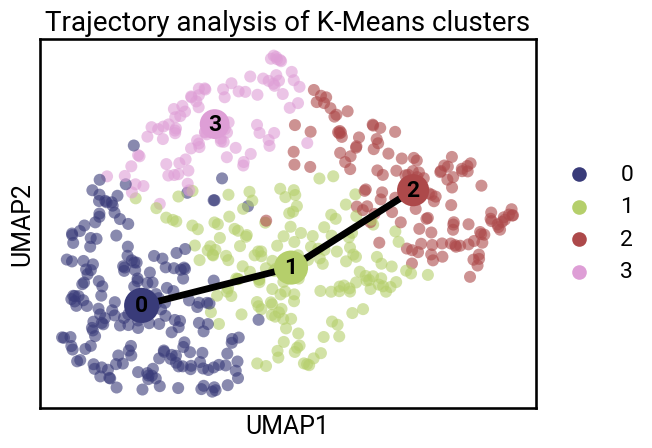

In [34]:
thr=0.35
pos = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)
pos["group"] = adata.obs['leiden_0.5']
pos = pos.groupby("group", observed=True).mean()
ax=sc.pl.umap(adata,color='leiden_0.5',palette='tab20b',show=False,size=300,alpha=0.6)
# Plot PAGA ontop of the UMAP
ax2=sc.pl.paga(
    adata,
    color="leiden_0.5",
    threshold=thr,
    node_size_scale=3,
    edge_width_scale=1,
    pos=pos.values,
    random_state=42,
    ax=ax,normalize_to_color=True,show=False
)
_ = ax2.set_title("Trajectory analysis of K-Means clusters", fontsize=20)

In [35]:
trydf=adata.obs.groupby('true_labels')

C:\Users\anous\AppData\Local\Temp\ipykernel_13124\310312704.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trydf=adata.obs.groupby('true_labels')


In [36]:
import matplotlib.cm as cm


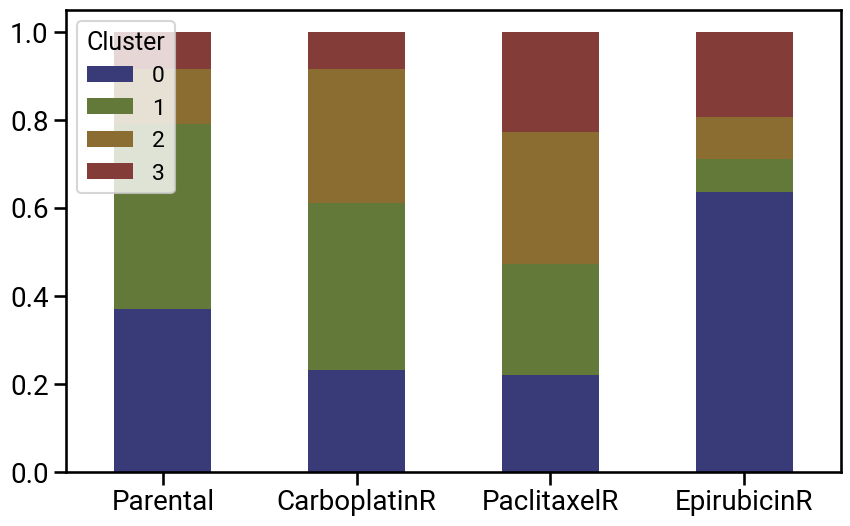

In [38]:

cluster_order =['0','1','2','3']

cmap = plt.get_cmap("tab20b",6)

stacked_df = trydf['leiden_0.5'].value_counts(normalize=True).unstack()
stacked_df = stacked_df[cluster_order]

ax = stacked_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    fontsize=20,
    color=[cmap(i) for i in range(6)],
    rot=0
)
ax.legend(title='Cluster',loc='upper left')
plt.xlabel('')
plt.savefig('comp.svg',bbox_inches='tight',dpi=300)

C:\Users\anous\AppData\Local\Temp\ipykernel_13124\2543476952.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20b')


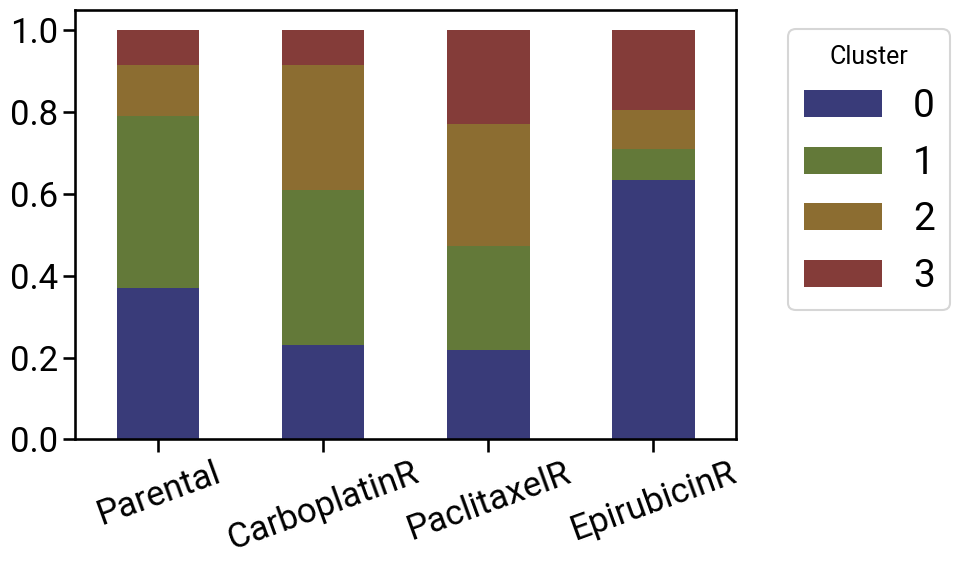

In [39]:
n_clusters = 6
# Get colors from the 'seismic' colormap
cmap = cm.get_cmap('tab20b')
color_map = {u: cmap(i % 20) for i, u in enumerate(uniq)}
colors = [cmap(i / (n_clusters - 1)) for i in range(n_clusters)]
ax = trydf['leiden_0.5'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(10, 6), fontsize=25, color=colors, rot=20
)
ax.grid(False)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), fontsize=28,loc='upper left')
plt.xlabel('')
plt.tight_layout()
plt.savefig('comp.svg',bbox_inches='tight',dpi=300)

In [40]:
zernikecell=reference.iloc[:,19:515]

In [41]:
zernikecell

,image_distance1_1,image_distance1_2,image_distance1_3,image_distance1_4,image_distance1_5,image_distance1_6,image_distance1_7,image_distance1_8,image_distance1_9,image_distance1_10,...,image_distance1_487,image_distance1_488,image_distance1_489,image_distance1_490,image_distance1_491,image_distance1_492,image_distance1_493,image_distance1_494,image_distance1_495,image_distance1_496
0,0.078905,-0.000232,0.000125,-7.700000e-06,-0.201517,0.023947,0.006194,0.006674,-0.015988,-0.008529,...,-0.025598,0.006760,0.006676,-1.307480e-02,0.008989,-0.003053,0.000557,0.000045,0.000001,0.000083
1,0.099516,-0.000328,0.000182,-1.240000e-05,-0.195669,0.088456,-0.011159,-0.009249,0.023205,0.018103,...,0.004635,-0.033944,0.057177,-1.068544e-02,-0.015984,0.009842,-0.003203,0.000581,-0.000344,-0.000044
2,0.050495,-0.000112,-0.000167,-8.200000e-06,-0.140275,0.006367,-0.000354,0.000103,0.001512,0.001485,...,-0.003275,-0.000525,0.000194,-3.169210e-04,0.000168,-0.000329,0.000066,-0.000193,0.000048,-0.000238
3,0.040746,-0.000165,-0.000040,4.560000e-07,-0.113797,0.006584,-0.000381,0.000224,-0.000810,-0.000519,...,-0.002886,0.000422,-0.000034,-5.180000e-05,0.000171,-0.000021,-0.000016,0.000040,0.000033,0.000044
4,0.103194,-0.000362,-0.000168,2.540000e-06,-0.265553,0.026313,0.005651,0.004854,-0.005657,-0.002793,...,0.031119,-0.012879,-0.001828,1.916947e-03,-0.000368,-0.000070,0.000090,-0.000072,0.000213,-0.000100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,0.067342,-0.000230,-0.000090,4.480000e-06,-0.186679,0.003084,-0.000889,0.001187,0.000019,0.001157,...,-0.005046,0.000786,-0.000019,6.800000e-07,0.000055,0.000047,0.000173,0.000068,0.000228,0.000080
564,0.099141,0.000253,-0.000303,5.410000e-06,-0.260038,0.020839,-0.001092,-0.001455,-0.001518,-0.002866,...,-0.027026,0.015684,-0.003668,7.093000e-04,-0.000277,0.000212,-0.000039,0.000119,-0.000166,0.000121
565,0.088262,0.000221,-0.000269,1.780000e-06,-0.233049,0.020488,0.000545,-0.000332,0.003345,0.001190,...,-0.062495,0.041131,-0.015259,3.758888e-03,-0.000813,0.000204,-0.000108,0.000096,-0.000119,0.000036
566,0.075192,-0.000076,-0.000285,-1.130000e-06,-0.196311,0.023458,-0.000791,-0.000397,0.003934,0.001458,...,-0.033550,0.017490,-0.004765,4.524980e-04,0.000136,-0.000414,0.000362,-0.000342,0.000276,-0.000375


In [42]:
zernikenuclei=reference.iloc[:,515:1011]

In [43]:
zernikecell['cluster']=adata.obs["leiden_0.5"].to_numpy() 

In [44]:
zernikenuclei['cluster']=adata.obs['leiden_0.5'].to_numpy()

In [45]:
grouped_data_n=zernikenuclei.groupby('cluster').mean()
grouped_data=zernikecell.groupby('cluster').mean()

In [46]:
grouped_data

,image_distance1_1,image_distance1_2,image_distance1_3,image_distance1_4,image_distance1_5,image_distance1_6,image_distance1_7,image_distance1_8,image_distance1_9,image_distance1_10,...,image_distance1_487,image_distance1_488,image_distance1_489,image_distance1_490,image_distance1_491,image_distance1_492,image_distance1_493,image_distance1_494,image_distance1_495,image_distance1_496
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.066855,-0.000120,-0.000107,-1.257645e-07,-0.179311,0.010272,0.000311,0.000635,-0.000231,-0.000190,...,-0.002485,0.000925,0.000078,-0.000397,0.000204,-0.000087,0.000024,-0.000037,0.000027,-0.000036
1,0.079598,-0.000147,-0.000132,-1.319712e-08,-0.204674,0.020122,-0.000882,-0.000084,0.000085,-0.000302,...,-0.003382,0.002209,-0.001405,-0.000208,-0.000269,0.000597,-0.000033,-0.000408,0.000322,-0.000135
2,0.072671,-0.000075,0.000065,1.682400e-05,-0.180936,0.026212,0.000042,0.000714,0.001168,0.000478,...,-0.014534,0.011245,-0.007902,0.003605,-0.000673,0.000107,-0.000387,0.000568,-0.000528,0.000383
3,0.056205,-0.000092,-0.000099,2.697859e-07,-0.141725,0.024045,-0.000131,0.000220,-0.000275,-0.000359,...,-0.021251,0.017543,-0.013428,0.009032,-0.004877,0.002095,-0.001026,0.000828,-0.000511,0.000219


In [47]:
grouped_data_n.to_csv('zernikemean_n.csv')
grouped_data.to_csv('zernikemean.csv')

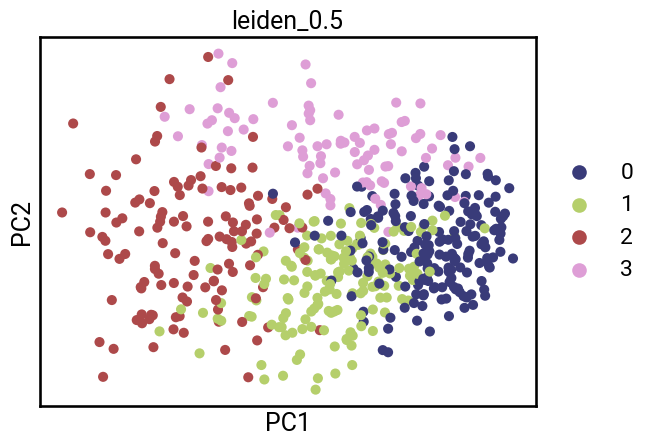

In [50]:
sc.pl.pca(adata, color='leiden_0.5')

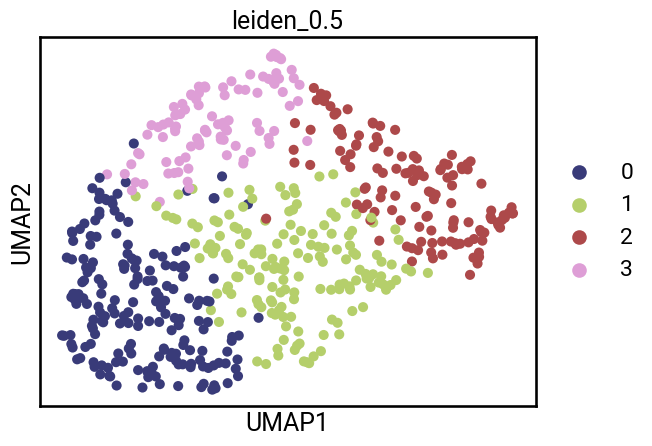

In [51]:
sc.pl.umap(adata, color='leiden_0.5')

In [48]:
cluster_means = (
    pd.DataFrame(adata.X, columns=adata.var_names)
    .assign(cluster=adata.obs["leiden_0.5"].values)
    .groupby("cluster")
    .mean()
)

C:\Users\anous\AppData\Local\Temp\ipykernel_13124\1896167498.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cluster")


In [49]:
cluster_means

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.097777,-0.091729,0.152955,-0.149705,-0.223076,0.629296,0.532178,-0.365558,0.106950,0.747884,...,0.124148,-0.410166,0.244148,-0.035345,0.481514,-0.430729,0.045748,-0.471191,-0.067026,0.512247
1,0.055454,-0.425590,0.211602,-0.646427,-0.301813,0.011801,0.027437,-0.059395,-0.005553,-0.140542,...,-0.302940,0.185730,0.042106,-0.395483,-0.224278,-0.393992,-0.057673,-0.146127,-0.485642,0.384158
2,-0.552130,-0.004112,-0.440343,0.439350,0.139828,-0.800767,-0.883151,0.570809,-0.427297,-0.675083,...,-0.310912,0.759972,-0.244960,-0.045981,-0.695978,0.902603,-0.490735,0.811922,0.354528,-0.958241
3,0.466250,0.945162,-0.076274,0.841470,0.792712,-0.187773,0.094596,0.056331,0.383468,-0.331115,...,0.714929,-0.548908,-0.230052,0.835626,0.384619,0.322889,0.687117,0.090719,0.506538,-0.393468


In [50]:
sc.settings.set_figure_params(fontsize=12,vector_friendly=True,dpi=300,format='svg')

In [85]:
#which features define one cluster
top_features_per_cluster = []
for c in cluster_means.index:
    diff = (cluster_means.loc[c] - cluster_means.drop(c).mean())
    list=diff.abs().sort_values(ascending=False).head(3).index.values
    top_features_per_cluster.append(list.tolist())

In [86]:
selected_features = [f for sublist in top_features_per_cluster for f in sublist]

In [87]:
selected_featuresarray=np.array(selected_features)

In [88]:
selected_featuresarray

array(['337', '512', '138', '263', '496', '256', '138', '68', '64'],
      dtype='<U3')

In [170]:
selected_features2=selected_featuresarray[0:3]

In [171]:
selected_features3=selected_featuresarray[4:]

In [172]:
selected_features=np.concatenate((selected_features2,selected_features3))

In [173]:
selected_features=selected_features.tolist()

In [52]:
handcrafted_feats = [
    "Cell_RI", "Nucleus_RI", "Nucleolus_RI", "Lipid_RI",
    "Nucleus_area", "Nucleolus_area", "Lipid_area",
    "Cell Area Total", "Cell Dry Mass", "Cell Thickness",
    "Cell Density", "Lipid Mass",
    "Nucleus to Cell Area Ratio", "Nucleolus to Nucleus Ratio"
]

In [53]:
X_hand = prop[handcrafted_feats].astype(float)
corr = X_hand.corr().abs()

In [54]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

handcrafted_pruned = [f for f in handcrafted_feats if f not in to_drop]